<a href="https://colab.research.google.com/github/HasiniReddyRavula1234/Machine-Learning-Projects/blob/main/Credit_Card_Analysis_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

wise_c_2_credit_card_default_risk_analysis_path = kagglehub.competition_download('wise-c-2-credit-card-default-risk-analysis')
hasinireddyravula_credit_card_analysis_hackathon_data_path = kagglehub.dataset_download('hasinireddyravula/credit-card-analysis-hackathon-data')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/wise-c-2-credit-card-default-risk-analysis/sample_submission.csv
/kaggle/input/competitions/wise-c-2-credit-card-default-risk-analysis/train.csv
/kaggle/input/competitions/wise-c-2-credit-card-default-risk-analysis/test.csv


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
train_df= pd.read_csv('/kaggle/input/datasets/hasinireddyravula/credit-card-analysis-hackathon-data/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/hasinireddyravula/credit-card-analysis-hackathon-data/test.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,27000,30000,1,2,2,25,0,0,0,0,...,11581,12580,13716,14828,1500,2000,1500,1500,1500,2000
1,27001,150000,2,1,2,26,0,0,0,0,...,116684,101581,77741,77264,4486,4235,3161,2647,2669,2669
2,27002,70000,2,3,1,32,0,0,0,0,...,68530,69753,70111,70212,2431,3112,3000,2438,2500,2554
3,27003,130000,1,3,2,49,0,0,0,0,...,16172,16898,11236,6944,1610,1808,7014,27,7011,4408
4,27004,50000,2,2,2,36,0,0,0,0,...,42361,19574,20295,19439,2000,1500,1000,1800,0,1000


In [ ]:
train_df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,27000.00000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000,...,27000.000000,27000.000000,27000.000000,27000.000000,2.700000e+04,27000.000000,27000.000000,27000.000000,27000.000000,27000.000000
mean,13499.50000,167720.728889,1.603222,1.851667,1.552963,35.486778,-0.015593,-0.132407,-0.167593,-0.219407,...,43323.950148,40387.517852,38937.254593,5696.015889,5.986320e+03,5263.971296,4866.874519,4831.716741,5215.986519,0.221370
std,7794.37297,129930.809212,0.489238,0.791893,0.522478,9.213408,1.127431,1.197978,1.192726,1.166120,...,64555.808717,60975.562843,59684.515387,16840.646208,2.377914e+04,18001.091009,16021.590858,15499.162587,17681.861320,0.415177
min,0.00000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6749.75000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2384.500000,1780.000000,1270.750000,1000.000000,8.710000e+02,390.000000,298.000000,259.000000,130.000000,0.000000
50%,13499.50000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19078.500000,18135.000000,17135.000000,2100.000000,2.013000e+03,1800.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,20249.25000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54345.500000,50149.000000,49205.250000,5012.000000,5.000000e+03,4532.250000,4010.000000,4051.000000,4000.000000,0.000000
max,26999.00000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,527143.000000,1.000000


In [ ]:
print(train_df.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [ ]:
train_df["default payment next month"].value_counts()

default payment next month
0    21023
1     5977
Name: count, dtype: int64

In [ ]:
train_df.shape

(27000, 25)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27000 entries, 0 to 26999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          27000 non-null  int64
 1   LIMIT_BAL                   27000 non-null  int64
 2   SEX                         27000 non-null  int64
 3   EDUCATION                   27000 non-null  int64
 4   MARRIAGE                    27000 non-null  int64
 5   AGE                         27000 non-null  int64
 6   PAY_0                       27000 non-null  int64
 7   PAY_2                       27000 non-null  int64
 8   PAY_3                       27000 non-null  int64
 9   PAY_4                       27000 non-null  int64
 10  PAY_5                       27000 non-null  int64
 11  PAY_6                       27000 non-null  int64
 12  BILL_AMT1                   27000 non-null  int64
 13  BILL_AMT2                   27000 non-null  int64
 14  BILL_A

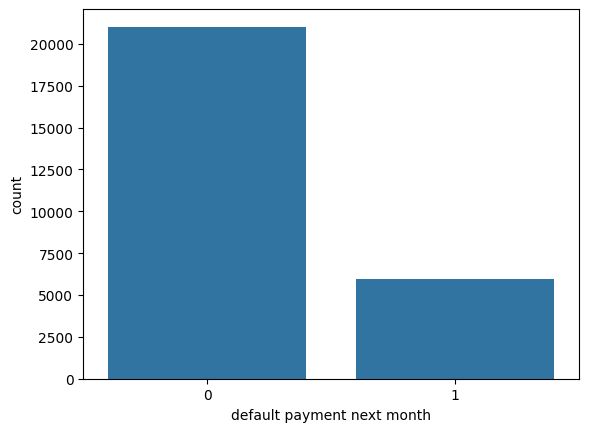

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x = "default payment next month", data = train_df)
plt.show()

In [ ]:
train_df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [ ]:
X = train_df.drop(["ID","default payment next month"], axis = 1)
test_id = test_df["ID"]
test_df = test_df.drop(["ID"], axis = 1)
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,100000,2,2,2,26,-1,-1,-1,0,0,...,4159,3542,1980,3980,4210,4159,1000,1080,2000,1525
1,100000,1,2,1,47,0,0,2,0,0,...,69111,64287,67838,66135,7000,0,2500,5500,0,3000
2,30000,2,2,2,23,3,3,3,3,2,...,29954,29176,29958,30520,1200,1200,0,1400,1200,0
3,280000,2,1,2,31,2,-1,-1,-2,-2,...,0,0,0,0,168,0,0,0,0,0
4,210000,1,2,1,54,2,-1,-1,-1,-1,...,195,485,210,3483,176,195,485,0,4466,417


In [ ]:
y = train_df["default payment next month"]
print(X.shape)
print(y.shape)

(27000, 23)
(27000,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier( n_estimators=300, max_depth=10, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import f1_score
print(f1_score(y_test,y_pred))


0.5418060200668896


In [ ]:
model.fit(X,y)
prediction = model.predict(test_df)

In [ ]:
submission = pd.DataFrame({
    "ID": test_id,
    "default payment next month": prediction
})
submission.to_csv("Submission.csv", index = False)
submission.head()

,ID,default payment next month
0,27000,0
1,27001,0
2,27002,0
3,27003,0
4,27004,0
